In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests # Để tải ảnh placeholder
import os # Để xử lý tệp

def download_placeholder_image(filename="placeholder.jpg"):
    """
    Tải ảnh placeholder nếu tệp ảnh không tồn tại.
    """
    if not os.path.exists(filename):
        print(f"Không tìm thấy tệp '{filename}'. Đang tải ảnh placeholder...")
        try:
            # Sử dụng placehold.co cho một ảnh chân dung placeholder
            url = "https://placehold.co/600x800/EEE/333?text=Sua+anh\\no+day\\n(Replace+me)"
            response = requests.get(url)
            response.raise_for_status() # Kiểm tra lỗi HTTP
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f"Đã tải ảnh placeholder thành công và lưu với tên '{filename}'.")
        except requests.exceptions.RequestException as e:
            print(f"Lỗi khi tải ảnh placeholder: {e}")
            return False
    return True

def image_to_sketch(image_path):
    """
    Chuyển đổi một ảnh tại đường dẫn đã cho thành ảnh phác thảo.
    """
    # 1. Đọc ảnh
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"Lỗi: Không thể đọc ảnh từ đường dẫn: {image_path}")
        return None, None

    # 2. Chuyển sang ảnh thang độ xám
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Đảo ngược ảnh xám (tạo ảnh âm bản)
    invert_img = 255 - gray_img

    # 4. Áp dụng hiệu ứng mờ Gaussian
    # Bạn có thể điều chỉnh (21, 21) để thay đổi độ dày của nét phác thảo
    # Số lớn hơn = nét dày hơn
    blur_img = cv2.GaussianBlur(invert_img, (121, 121), 0)

    # 5. Đảo ngược ảnh đã làm mờ
    invert_blur_img = 255 - blur_img

    # 6. Tạo ảnh phác thảo bằng cách "Color Dodge"
    # (Chia ảnh xám cho ảnh mờ đã đảo ngược)
    sketch_img = cv2.divide(gray_img, invert_blur_img, scale=256.0)

    # Chuyển đổi ảnh gốc BGR sang RGB để matplotlib hiển thị đúng màu
    rgb_original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return rgb_original_img, sketch_img

def main():
    # --- THAY ĐỔI TẠI ĐÂY ---
    # Thay thế "placeholder.jpg" bằng đường dẫn đến tệp ảnh chân dung của bạn
    # Ví dụ: "anh_cua_toi.jpg" hoặc "C:/NguoiDung/Toi/Anh/chan_dung.png"
    image_file = "1.jpg"
    # ---------------------

    # Tải ảnh placeholder nếu ảnh người dùng chỉ định không tồn tại
    if not os.path.exists(image_file):
        if not download_placeholder_image(image_file):
            return # Thoát nếu không tải được placeholder

    # Gọi hàm chuyển đổi
    original, sketch = image_to_sketch(image_file)

    if original is not None and sketch is not None:
        # --- Lưu kết quả ---
        save_path = "anh_phac_thao.jpg"
        cv2.imwrite(save_path, sketch)
        print(f"Đã lưu ảnh phác thảo thành công tại: {save_path}")

        # --- Hiển thị kết quả ---
        plt.figure(figsize=(10, 5))

        # Ảnh gốc
        plt.subplot(1, 2, 1)
        plt.title("Ảnh gốc")
        plt.imshow(original)
        plt.axis("off")

        # Ảnh phác thảo
        plt.subplot(1, 2, 2)
        plt.title("Ảnh phác thảo")
        plt.imshow(sketch, cmap="gray") # Sử dụng colormap 'gray' cho ảnh đen trắng
        plt.axis("off")

        plt.suptitle(f"Chuyển đổi ảnh sang phác thảo (Nguồn: {image_file})", fontsize=16)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()




In [39]:
import cv2
import numpy as np

def photo_to_sketch(image_path, output_path="sketch_better.png",
                    sigma=0.8, k=2, gamma=0.96, epsilon=0.05, phi=1.2):
    # Đọc ảnh và chuyển sang grayscale
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    # Gaussian blur (2 mức)
    G1 = cv2.GaussianBlur(gray, (0, 0), sigma)
    G2 = cv2.GaussianBlur(gray, (0, 0), sigma * k)

    # XDoG filter
    D = G1 - gamma * G2
    D_norm = D / np.max(D)

    # Điều chỉnh độ đậm nhạt của nét
    sketch = np.where(D_norm >= epsilon, 1.0, 1.0 + np.tanh(phi * (D_norm - epsilon)))

    # Làm sáng ảnh để không bị tối
    sketch = (sketch * 255).astype(np.uint8)
    sketch = cv2.equalizeHist(sketch)       # cân bằng sáng tối
    # sketch = 255 - sketch                   # đảo màu

    cv2.imwrite(output_path, sketch)
    print(f"✅ Ảnh sketch đã lưu tại: {output_path}")

# Ví dụ dùng:
photo_to_sketch("0.jpg", "sketch_result.jpg")


✅ Ảnh sketch đã lưu tại: sketch_result.jpg


In [52]:
import cv2
import numpy as np
import os

def photo_to_sketch_folder(input_folder, output_folder="sketch_results",
                           sigma=0.8, k=2, gamma=0.96, epsilon=0.05, phi=1.2):
    """
    Chuyển toàn bộ ảnh trong thư mục input thành sketch và lưu vào thư mục output.

    Parameters:
        input_folder (str): Đường dẫn đến thư mục chứa ảnh gốc.
        output_folder (str): Thư mục để lưu ảnh sketch.
        sigma, k, gamma, epsilon, phi: Các tham số điều chỉnh bộ lọc XDoG.
    """
    # Tạo thư mục output nếu chưa có
    os.makedirs(output_folder, exist_ok=True)

    # Duyệt qua toàn bộ file trong thư mục
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
            image_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, f"{filename}")

            # Đọc ảnh và xử lý
            img = cv2.imread(image_path)
            if img is None:
                print(f"⚠️ Không thể đọc ảnh: {filename}")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = gray / 255.0

            # Gaussian blur
            G1 = cv2.GaussianBlur(gray, (0, 0), sigma)
            G2 = cv2.GaussianBlur(gray, (0, 0), sigma * k)

            # XDoG filter
            D = G1 - gamma * G2
            D_norm = D / np.max(D)

            # Tăng độ tương phản nét vẽ
            sketch = np.where(D_norm >= epsilon, 1.0, 1.0 + np.tanh(phi * (D_norm - epsilon)))

            # Cân bằng sáng tối
            sketch = (sketch * 255).astype(np.uint8)
            sketch = cv2.equalizeHist(sketch)
            # sketch = 255 - sketch   # Nếu muốn đảo màu

            cv2.imwrite(output_path, sketch)
            print(f"✅ Đã xử lý: {filename} → {output_path}")

    print("\n🎨 Hoàn tất! Toàn bộ ảnh sketch được lưu tại:", output_folder)

# --- Ví dụ sử dụng ---
photo_to_sketch_folder("images", "images_sketch")


✅ Đã xử lý: 0.jpg → images_sketch\0.jpg
✅ Đã xử lý: 1.jpg → images_sketch\1.jpg
✅ Đã xử lý: 10.jpg → images_sketch\10.jpg
✅ Đã xử lý: 100.jpg → images_sketch\100.jpg
✅ Đã xử lý: 1000.jpg → images_sketch\1000.jpg
✅ Đã xử lý: 10000.jpg → images_sketch\10000.jpg
✅ Đã xử lý: 10001.jpg → images_sketch\10001.jpg
✅ Đã xử lý: 10002.jpg → images_sketch\10002.jpg
✅ Đã xử lý: 10003.jpg → images_sketch\10003.jpg
✅ Đã xử lý: 10004.jpg → images_sketch\10004.jpg
✅ Đã xử lý: 10005.jpg → images_sketch\10005.jpg
✅ Đã xử lý: 10006.jpg → images_sketch\10006.jpg
✅ Đã xử lý: 10007.jpg → images_sketch\10007.jpg
✅ Đã xử lý: 10008.jpg → images_sketch\10008.jpg
✅ Đã xử lý: 10009.jpg → images_sketch\10009.jpg
✅ Đã xử lý: 1001.jpg → images_sketch\1001.jpg
✅ Đã xử lý: 10010.jpg → images_sketch\10010.jpg
✅ Đã xử lý: 10011.jpg → images_sketch\10011.jpg
✅ Đã xử lý: 10012.jpg → images_sketch\10012.jpg
✅ Đã xử lý: 10013.jpg → images_sketch\10013.jpg
✅ Đã xử lý: 10014.jpg → images_sketch\10014.jpg
✅ Đã xử lý: 10015.jpg 

In [54]:
import os
import cv2
import random
import shutil
from glob import glob

# ==== Đường dẫn gốc ====
sketch_dir = r"images_sketch"       # thư mục chứa ảnh sketch (.jpg)
caption_dir = r"celeba-caption"     # thư mục chứa caption .txt
output_dir = r"dataset"             # thư mục đầu ra sau xử lý

# ==== Thông số ====
img_size = (128, 128)
split_ratio = {'train': 0.8, 'val': 0.1, 'test': 0.1}
MAX_SAMPLES = 10000   # số lượng mẫu tối đa muốn lấy (đặt None nếu muốn lấy toàn bộ)
random.seed(42)

# ==== Tạo folder đầu ra ====
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, split, 'texts'), exist_ok=True)

# ==== Lấy danh sách ảnh ====
image_files = sorted(glob(os.path.join(sketch_dir, "*.jpg")))
print(f"📷 Found {len(image_files)} images in total")

# ==== Giới hạn số lượng mẫu nếu cần ====
if MAX_SAMPLES is not None and MAX_SAMPLES < len(image_files):
    image_files = random.sample(image_files, MAX_SAMPLES)
    print(f"🎯 Using only {MAX_SAMPLES} samples")

# ==== Shuffle và chia ====
random.shuffle(image_files)
n_total = len(image_files)
n_train = int(n_total * split_ratio['train'])
n_val = int(n_total * split_ratio['val'])

splits = {
    'train': image_files[:n_train],
    'val': image_files[n_train:n_train + n_val],
    'test': image_files[n_train + n_val:]
}

# ==== Hàm xử lý ảnh + text ====
def process_split(split_name, file_list):
    for path in file_list:
        filename = os.path.basename(path)
        name, _ = os.path.splitext(filename)

        img_out_path = os.path.join(output_dir, split_name, 'images', filename)
        txt_in_path  = os.path.join(caption_dir, name + ".txt")
        txt_out_path = os.path.join(output_dir, split_name, 'texts', name + ".txt")

        # Đọc và resize ảnh
        img = cv2.imread(path)
        if img is None:
            print(f"⚠️ Could not read {filename}")
            continue

        img = cv2.resize(img, img_size)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(img_out_path, gray)

        # Copy text nếu có
        if os.path.exists(txt_in_path):
            shutil.copy(txt_in_path, txt_out_path)
        else:
            print(f"⚠️ Missing caption for {name}")

    print(f"✅ {split_name.upper()} set done: {len(file_list)} samples")

# ==== Chạy xử lý ====
for split, files in splits.items():
    process_split(split, files)

print("\n🎉 Dataset processed: resized 128×128, converted to grayscale, and split into train/val/test.")


📷 Found 30000 images in total
🎯 Using only 10000 samples
✅ TRAIN set done: 8000 samples
✅ VAL set done: 1000 samples
✅ TEST set done: 1000 samples

🎉 Dataset processed: resized 128×128, converted to grayscale, and split into train/val/test.


In [58]:
import cv2
import numpy as np

def photo_to_sketch_refined(image_path, output_path="sketch_refined.png",
                            sigma=0.4, k=1, gamma=0.8, epsilon=0.01, phi=30):
    # Đọc ảnh và chuyển sang grayscale
    img = cv2.imread(image_path)
    if img is None:
        print(f"Lỗi: Không thể đọc ảnh từ đường dẫn {image_path}")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0  # Chuẩn hóa về [0, 1]

    # Gaussian blur (2 mức)
    G1 = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
    G2 = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma * k, sigmaY=sigma * k)

    # XDoG filter
    # D càng lớn (tức là sự khác biệt giữa G1 và G2 càng lớn), nét càng mạnh
    D = G1 - gamma * G2

    # Áp dụng hàm sigmoid hoặc tanh để làm nổi bật nét
    # Giá trị phi cao sẽ làm nét sắc hơn
    sketch = 1.0 / (1.0 + np.exp(phi * (D - epsilon)))

    # Chuyển về thang 0-255
    sketch = (sketch * 255).astype(np.uint8)

    # Đảo màu để có nét đen trên nền trắng
    sketch = 255 - sketch

    cv2.imwrite(output_path, sketch)
    print(f"✅ Ảnh sketch đã lưu tại: {output_path}")

# Ví dụ sử dụng: Thay thế "0.jpg" bằng đường dẫn ảnh của bạn
photo_to_sketch_refined("0.jpg", "sketch_refined_result.jpg")

✅ Ảnh sketch đã lưu tại: sketch_refined_result.jpg


In [1]:
import os
import shutil
import random
import math

# --- BẠN CẦN THAY ĐỔI 2 ĐƯỜNG DẪN NÀY ---
# Đường dẫn đến thư mục gốc chứa 3 tập train, test, val
DATA_ROOT = 'dataset' 
# Đường dẫn đến thư mục mới nơi bạn muốn lưu bộ dữ liệu 1%
OUTPUT_ROOT = '1_percent_dataset' 
# ----------------------------------------

# Tỷ lệ phần trăm bạn muốn giữ lại (0.01 = 1%)
FRACTION = 0.01

# Các tập con (subsets)
splits = ['train', 'test', 'val']

print(f"Bắt đầu xử lý. Giữ lại {FRACTION*100}% dữ liệu.")
print(f"Nguồn: {DATA_ROOT}")
print(f"Đích: {OUTPUT_ROOT}")

# Tạo thư mục đích nếu chưa có
os.makedirs(OUTPUT_ROOT, exist_ok=True)

for split in splits:
    print(f"\nĐang xử lý tập: {split}")
    
    # Xác định đường dẫn
    image_dir = os.path.join(DATA_ROOT, split, 'images')
    text_dir = os.path.join(DATA_ROOT, split, 'texts')
    
    out_image_dir = os.path.join(OUTPUT_ROOT, split, 'images')
    out_text_dir = os.path.join(OUTPUT_ROOT, split, 'texts')
    
    # Tạo thư mục con trong thư mục đích
    os.makedirs(out_image_dir, exist_ok=True)
    os.makedirs(out_text_dir, exist_ok=True)
    
    # Kiểm tra xem thư mục nguồn có tồn tại không
    if not os.path.isdir(image_dir) or not os.path.isdir(text_dir):
        print(f"Cảnh báo: Không tìm thấy thư mục 'images' hoặc 'texts' trong {split}. Bỏ qua.")
        continue
        
    # Lấy danh sách tất cả các file ảnh
    try:
        image_files = [f for f in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, f))]
    except FileNotFoundError:
        print(f"Cảnh báo: Không tìm thấy thư mục {image_dir}. Bỏ qua.")
        continue
        
    if not image_files:
        print(f"Không tìm thấy file ảnh nào trong {image_dir}. Bỏ qua.")
        continue

    # Tính toán số lượng mẫu 1%
    num_total = len(image_files)
    # Dùng math.ceil để đảm bảo luôn lấy ít nhất 1 file nếu 1% < 1
    num_to_keep = math.ceil(num_total * FRACTION) 
    
    print(f"Tổng số file: {num_total}. Giữ lại: {num_to_keep} file.")
    
    # Lấy ngẫu nhiên các file ảnh
    selected_image_files = random.sample(image_files, num_to_keep)
    
    copied_count = 0
    # Sao chép các file đã chọn và file .txt tương ứng
    for img_file in selected_image_files:
        # Lấy tên file gốc (không bao gồm phần mở rộng)
        basename, img_ext = os.path.splitext(img_file)
        text_file = basename + '.txt'
        
        # Đường dẫn file nguồn
        src_img_path = os.path.join(image_dir, img_file)
        src_txt_path = os.path.join(text_dir, text_file)
        
        # Đường dẫn file đích
        dst_img_path = os.path.join(out_image_dir, img_file)
        dst_txt_path = os.path.join(out_text_dir, text_file)
        
        # Kiểm tra xem file .txt tương ứng có tồn tại không
        if os.path.exists(src_txt_path):
            # Sao chép file ảnh
            shutil.copy2(src_img_path, dst_img_path)
            # Sao chép file text
            shutil.copy2(src_txt_path, dst_txt_path)
            copied_count += 1
        else:
            print(f"Cảnh báo: Không tìm thấy file {text_file} tương ứng với {img_file}. Bỏ qua cặp file này.")
            
    print(f"Hoàn thành {split}. Đã sao chép {copied_count} cặp file (ảnh + text).")

print("\nXong! Đã tạo xong bộ dữ liệu 1%.")

Bắt đầu xử lý. Giữ lại 1.0% dữ liệu.
Nguồn: dataset
Đích: 1_percent_dataset

Đang xử lý tập: train
Tổng số file: 8000. Giữ lại: 80 file.
Hoàn thành train. Đã sao chép 80 cặp file (ảnh + text).

Đang xử lý tập: test
Tổng số file: 1000. Giữ lại: 10 file.
Hoàn thành test. Đã sao chép 10 cặp file (ảnh + text).

Đang xử lý tập: val
Tổng số file: 1000. Giữ lại: 10 file.
Hoàn thành val. Đã sao chép 10 cặp file (ảnh + text).

Xong! Đã tạo xong bộ dữ liệu 1%.


Đang tải tokenizer: openai/clip-vit-base-patch32...
Đang đọc các file và token hóa...
Đang xử lý thư mục: dataset/train/texts
Đang xử lý thư mục: dataset/test/texts
Đang xử lý thư mục: dataset/val/texts

--- Length statistics (number of TOKENs) ---
Total description: 100000
min: 5 token
max: 60 token
mean: 20.08 token
median: 19.0 token
90th percentile (P90): 30 token
95th percentile (P95): 34 token
99th percentile (P99): 40 token
Number of descriptions > 77 token: 0 (0.00%)

Đã lưu biểu đồ vào: token_length_distribution.png


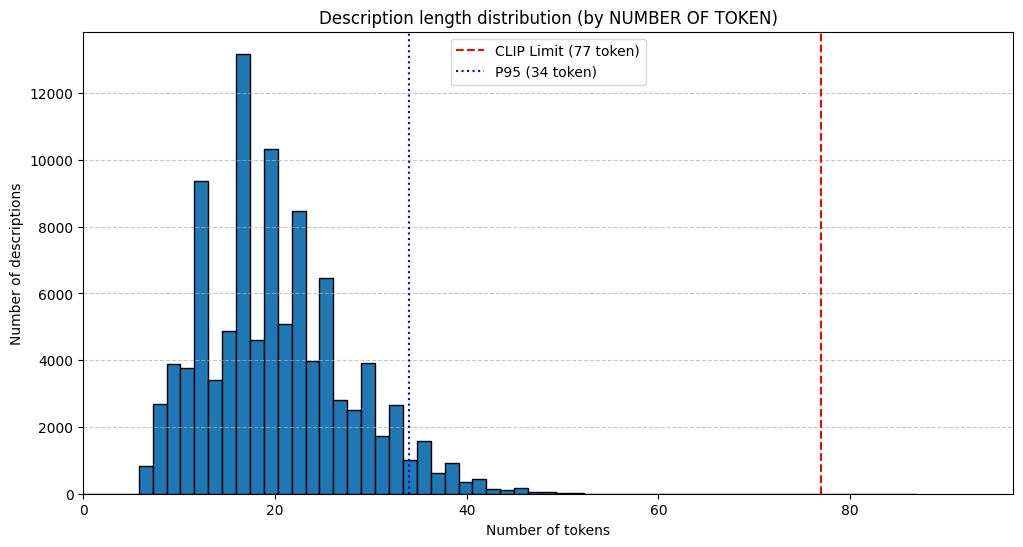

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from transformers import CLIPTokenizer # Cần cài đặt: pip install transformers

# --- Cấu hình ---
# Đường dẫn GỐC đến các thư mục chứa train/test/val
# Code sẽ tự động tìm 'texts' bên trong mỗi đường dẫn này
BASE_PATHS = {
    'train': 'dataset/train/',
    'test': 'dataset/test/',
    'val': 'dataset/val/'
}
# Tên thư mục con chứa các file text
TEXTS_SUBDIR = 'texts'

# Tên model CLIP bạn dự định dùng
TOKENIZER_NAME = 'openai/clip-vit-base-patch32'
# ------------------

token_lengths = []
all_dirs_found = True

try:
    print(f"Đang tải tokenizer: {TOKENIZER_NAME}...")
    tokenizer = CLIPTokenizer.from_pretrained(TOKENIZER_NAME)
except Exception as e:
    print(f"Lỗi khi tải tokenizer: {e}")
    print("Vui lòng kiểm tra tên model hoặc kết nối mạng.")
    exit()

print("Đang đọc các file và token hóa...")

for split, base_path in BASE_PATHS.items():
    # Tạo đường dẫn đầy đủ đến thư mục texts, ví dụ: 'train/texts'
    texts_dir = os.path.join(base_path, TEXTS_SUBDIR)
    
    if not os.path.isdir(texts_dir):
        print(f"CẢNH BÁO: Không tìm thấy thư mục: {texts_dir}")
        all_dirs_found = False
        continue
        
    print(f"Đang xử lý thư mục: {texts_dir}")
    
    # Lấy danh sách tất cả các file trong thư mục
    try:
        filenames = os.listdir(texts_dir)
    except Exception as e:
        print(f"Lỗi khi đọc thư mục {texts_dir}: {e}")
        continue

    # Lọc ra chỉ các file .txt
    txt_files = [f for f in filenames if f.endswith('.txt')]
    
    if not txt_files:
        print(f"CẢNH BÁO: Không tìm thấy file .txt nào trong {texts_dir}")
        continue
        
    # Đọc từng file .txt
    for filename in txt_files:
        file_path = os.path.join(texts_dir, filename)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                
                # --- LỰA CHỌN CÁCH ĐỌC FILE ---
                
                # --- GIẢ ĐỊNH 1: MỖI FILE .TXT CHỨA 1 MÔ TẢ DUY NHẤT ---
                # (Ví dụ: file 'image_001.txt' chứa "a photo of a cat")
                # text = f.read().strip()
                # if text:
                #     input_ids = tokenizer(text, padding=False, truncation=False).input_ids
                #     token_lengths.append(len(input_ids))
                
                # --- GIẢ ĐỊNH 2: MỖI FILE .TXT CHỨA NHIỀU MÔ TẢ (mỗi dòng 1 mô tả) ---
                # (Ví dụ: file 'image_001.txt' chứa 5 dòng mô tả)
                # Nếu bạn dùng giả định này, hãy comment 4 dòng của GIẢ ĐỊNH 1 ở trên
                # và bỏ comment 5 dòng dưới đây:
                for line in f:
                    text = line.strip()
                    if text:
                        input_ids = tokenizer(text, padding=False, truncation=False).input_ids
                        token_lengths.append(len(input_ids))
                
        except Exception as e:
            print(f"Lỗi khi đọc file {file_path}: {e}")

if not all_dirs_found and not token_lengths:
    print("Không tìm thấy bất kỳ thư mục 'texts' nào. Vui lòng kiểm tra lại BASE_PATHS.")
elif not token_lengths:
    print("Đã tìm thấy thư mục, nhưng không đọc được mô tả nào. Vui lòng kiểm tra nội dung file .txt.")
else:
    # --- PHẦN PHÂN TÍCH VÀ VẼ BIỂU ĐỒ (Giống như trước) ---
    
    lengths_arr = np.array(token_lengths)

    print("\n--- Length statistics (number of TOKENs) ---")
    print(f"Total description: {len(lengths_arr)}")
    print(f"min: {np.min(lengths_arr)} token")
    print(f"max: {np.max(lengths_arr)} token")
    print(f"mean: {np.mean(lengths_arr):.2f} token")
    print(f"median: {np.median(lengths_arr)} token")
    
    p90 = np.percentile(lengths_arr, 90)
    p95 = np.percentile(lengths_arr, 95)
    p99 = np.percentile(lengths_arr, 99)
    
    print(f"90th percentile (P90): {p90:.0f} token")
    print(f"95th percentile (P95): {p95:.0f} token")
    print(f"99th percentile (P99): {p99:.0f} token")

    CLIP_LIMIT = 77
    over_limit_count = np.sum(lengths_arr > CLIP_LIMIT)
    over_limit_percent = (over_limit_count / len(lengths_arr)) * 100
    
    print(f"Number of descriptions > {CLIP_LIMIT} token: {over_limit_count} ({over_limit_percent:.2f}%)")

    # --- Vẽ biểu đồ Histogram ---
    plt.figure(figsize=(12, 6))
    max_len = np.max(lengths_arr)
    bins = min(max_len, 200) 
    
    plt.hist(lengths_arr, bins=bins, edgecolor='black', range=(0, max(max_len, CLIP_LIMIT + 10)))
    plt.title('Description length distribution (by NUMBER OF TOKEN)')
    plt.xlabel('Number of tokens')
    plt.ylabel('Number of descriptions')
    
    plt.axvline(CLIP_LIMIT, color='red', linestyle='--', label=f'CLIP Limit ({CLIP_LIMIT} token)')
    plt.axvline(p95, color='blue', linestyle=':', label=f'P95 ({p95:.0f} token)')
    
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xlim(0, max(max_len + 5, CLIP_LIMIT + 20))
    
    output_image_path = 'token_length_distribution.png'
    plt.savefig(output_image_path)
    print(f"\nĐã lưu biểu đồ vào: {output_image_path}")